In [1]:
### KNN --- Scripting

In [2]:
### KNN --- Classification

In [52]:
# import necessary libraries
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [7]:
load_wine = load_wine()

In [9]:
wine_dataset = pd.DataFrame(data=load_wine.data,columns=load_wine.feature_names)
wine_dataset["Target"] = load_wine.target
wine_dataset.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [11]:
# data understanding

In [10]:
wine_dataset.shape

(178, 14)

In [12]:
wine_dataset.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object

In [13]:
wine_dataset.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [14]:
# model building

In [15]:
X = wine_dataset.drop(labels="Target",axis=1)
y = wine_dataset["Target"]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,stratify=y,random_state=101)

In [17]:
X_train.shape,X_test.shape

((142, 13), (36, 13))

In [18]:
y_train.shape,y_test.shape

((142,), (36,))

In [19]:
# Model training

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=3)

In [21]:
knn_model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
# Model testing

In [22]:
y_pred_train = knn_model.predict(X_train)

In [23]:
y_pred_train

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 2, 2, 1, 0, 2, 0, 0,
       1, 0, 0, 2, 2, 0, 0, 0, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1,
       2, 2, 1, 0, 1, 2, 1, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       2, 1, 1, 2, 0, 1, 0, 1, 0, 1, 0, 0, 2, 2, 1, 1, 0, 2, 0, 1, 0, 2,
       2, 1, 0, 0, 0, 2, 1, 2, 2, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2,
       1, 2, 1, 2, 1, 1, 2, 1, 1, 0, 2, 1, 0, 0, 2, 2, 2, 0, 0, 1, 0, 2,
       1, 1, 2, 1, 1, 0, 1, 1, 1, 0])

In [26]:
# Model Evaluation

In [24]:
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.8873


In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.8099


In [28]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.7676


In [29]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.7606


In [31]:
# Standard Scaler

In [35]:
std_scaler = StandardScaler()
scaled_X = std_scaler.fit_transform(X)

In [36]:
scaled_X

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [38]:
X_train,X_test,y_train,y_test = train_test_split(scaled_X,y,test_size=0.20,shuffle=True,stratify=y,random_state=101)

In [39]:
# Model training

In [40]:
knn_model = KNeighborsClassifier(n_neighbors=3)

In [41]:
knn_model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
# Model testing

In [43]:
y_pred_train = knn_model.predict(X_train)

In [44]:
y_pred_train

array([0, 0, 0, 0, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 2, 2, 0, 0, 0, 1, 1, 2, 1, 1, 2, 1, 0, 0, 0, 0, 2, 1, 1,
       2, 2, 1, 0, 2, 2, 1, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       2, 1, 1, 2, 1, 1, 0, 0, 0, 2, 1, 0, 2, 0, 1, 1, 0, 2, 0, 1, 0, 2,
       2, 1, 0, 0, 0, 2, 1, 2, 2, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2,
       1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 0, 0, 2, 2, 2, 0, 0, 1, 0, 1,
       1, 1, 2, 1, 0, 0, 1, 1, 1, 0])

In [45]:
# Model Evaluation

In [46]:
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9718


In [47]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789


In [48]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789


In [49]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9859


In [50]:
# How to choose the optimal number of neighbours?

In [51]:
# step 1 crete a for loop - 3 to 51 neighbours
# step 2 KNN (neighbours =i)
# step 3 cross validation(k-fold)
# step 4 cal mean
# step 5 store it in a list

In [60]:
kfold = KFold(n_splits=5, shuffle=True, random_state=101)
cv_scores_mean = []

for i in range(3,52,2):
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(scaled_X,y)
    
    cv_scores = cross_val_score(estimator=knn_model,X=scaled_X,y=y,cv=kfold)
    cv_scores_mean.append(cv_scores.mean().round(4))

In [61]:
cv_scores_mean

[np.float64(0.9663),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9662),
 np.float64(0.9662),
 np.float64(0.9773),
 np.float64(0.9662),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9605)]

In [62]:
max(cv_scores_mean)

np.float64(0.9773)

In [63]:
cv_scores_mean

[np.float64(0.9663),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9662),
 np.float64(0.9662),
 np.float64(0.9773),
 np.float64(0.9662),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9605)]

In [69]:
cv_scores_mean.index(max(cv_scores_mean))  # neighbours = 7

2

In [65]:
# Visualize this

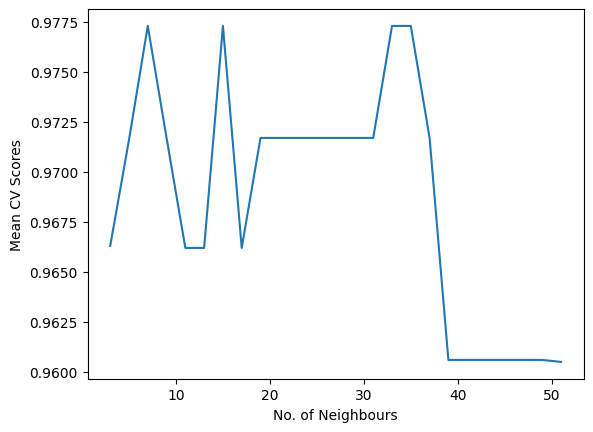

In [68]:
plt.plot(range(3,52,2),cv_scores_mean)
plt.xlabel("No. of Neighbours")
plt.ylabel("Mean CV Scores")
plt.show()

In [70]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train,y_train)
y_pred_train = knn_model.predict(X_train)
print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789


### The End!!!